# Beta-hedged backtest: long Q5 into D, short after D, market exposure hedged with TAIEX futures

**Why.** `backtest.ipynb` found the unhedged 12-day long is mostly market exposure: its worst dates are the COVID and
tariff crashes, when a dozen long positions fell with the market at once. This notebook removes that exposure. Every
position carries an opposite TAIEX futures position sized by the stock's beta, so P&L is the stock's move *relative to
the market*.

**Same trade as `backtest.ipynb`.** Q5 = days-to-cover on D−17 ≥ **0.167** (frozen), 20-day turnover ≥ NT$20m. Buy at the
close of D−k, flip to short at the close of D, cover at the close of D+h. Single-stock futures, 20bp per leg (stock
returns as the proxy, as in `backtest.ipynb`).

**The hedge.**
* **Beta per event**, estimated on data known at the signal date: daily returns over the 250 trading days ending at
  **D−17**. **Dimson beta** (slopes on today's, yesterday's and the day before's TAIEX return, summed), because thinly
  traded small caps react to the market with a lag and a same-day regression understates their beta. Days at the ±10%
  price limit are dropped. Then **Blume shrinkage**, β = 0.67·β_raw + 0.33, since single-stock betas are noisy. Fewer than
  60 usable days → β = 1.
* **Position:** long leg = long 1 stock, short β TAIEX futures; short leg = short 1 stock, long β TAIEX futures. The
  hedge flips with the stock at D.
* **Hedge return:** TAIEX total return minus a 1.5% risk-free rate (an index future earns the total return less
  financing). **Hedge cost:** 2bp per leg on β × notional (TX/MTX: futures tax 0.2bp, commission, one tick of spread).
* In practice, net the β-weighted notional across all open positions and hedge the sum with MTX/TMF contracts. That
  is the same P&L as hedging each position separately, with far less turnover. The 2bp per position is conservative.

## 1. Data, events, signal
**What this does.** Same construction as `backtest.ipynb`: the TWSE panel, the ban calendar, days-to-cover on D−17, the
frozen threshold and liquidity filter, and the in-sample / out-of-sample label.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
K, H = 12, 5                 # frozen trade from backtest.ipynb: long from the close of D-12 to D, short from the close of D to D+5
THR = 0.167                  # frozen: in-sample 80th pct of days-to-cover on D-17 (insample.ipynb)
SIG_LAG, MIN_VAL20, COST_LEG_BPS = 17, 2e7, 20
K_MAX, H_MAX = 15, 20        # grid: long entry up to D-15, short held up to 20 days
BETA_WIN, BETA_MIN, DIMSON_LAGS = 250, 60, 2
HEDGE_BPS, RF = 2, 0.015

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)
R = wide(px, "ret")
SB = wide(mg, "short_bal")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T = len(cal); Rv = R.values
CUT = int(T * 2 / 3)
taiex = idx.taiex_tr.pct_change(fill_method=None).fillna(0).values
HEDGE_R = taiex - RF / 252                     # what a long TAIEX future earns per day

ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["D"] = cal.searchsorted(ev.date.values)
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.D + H + 1 < T)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
s_ = ev.D.values - SIG_LAG
ev["dtc"] = SB.values[s_, ev.j.values] / ADV.values[s_, ev.j.values]
ev["val20"] = VAL20.values[s_, ev.j.values]
ev["Ddate"] = cal[ev.D.values]
ev["period"] = np.select([ev.D + H_MAX < CUT, ev.D - K >= CUT], ["in-sample", "out-of-sample"], "boundary")
tr = ev[(SB.values[s_, ev.j.values] > 0) & (ev.dtc >= THR) & (ev.val20 >= MIN_VAL20) & (ev.period != "boundary")].reset_index(drop=True)
print(f"in-sample {cal[0].date()} -> {cal[CUT - 1].date()} | out-of-sample {cal[CUT].date()} -> {cal[-1].date()}")
print(tr.groupby("period").agg(trades=("D", "size"), deadline_dates=("Ddate", "nunique"), stocks=("stock_id", "nunique"),
                                first=("Ddate", "min"), last=("Ddate", "max")).to_string())

in-sample 2018-01-02 -> 2023-10-25 | out-of-sample 2023-10-26 -> 2026-09-23
               trades  deadline_dates  stocks      first       last
period                                                             
in-sample        1059             361     396 2018-03-05 2023-09-21
out-of-sample     208             103     156 2023-11-14 2026-09-02


## 2. Beta of each event
**What this does.** Estimates each event's beta on the 250 days ending at D−17, three ways: plain same-day OLS, Dimson
(sum of the lag 0, 1, 2 slopes) and Dimson with Blume shrinkage (the one used for the hedge). The gap between plain OLS
and Dimson shows how much the lagged reaction of thinly traded names hides.

events without enough history (beta set to 1): 122 of 1267
       beta_ols  beta_dimson     beta
count   1145.00      1145.00  1267.00
mean       1.01         1.16     1.09
std        0.43         0.50     0.32
min       -0.27        -0.23     0.17
25%        0.69         0.83     0.91
50%        1.00         1.14     1.05
75%        1.32         1.45     1.27
max        2.33         2.75     2.17


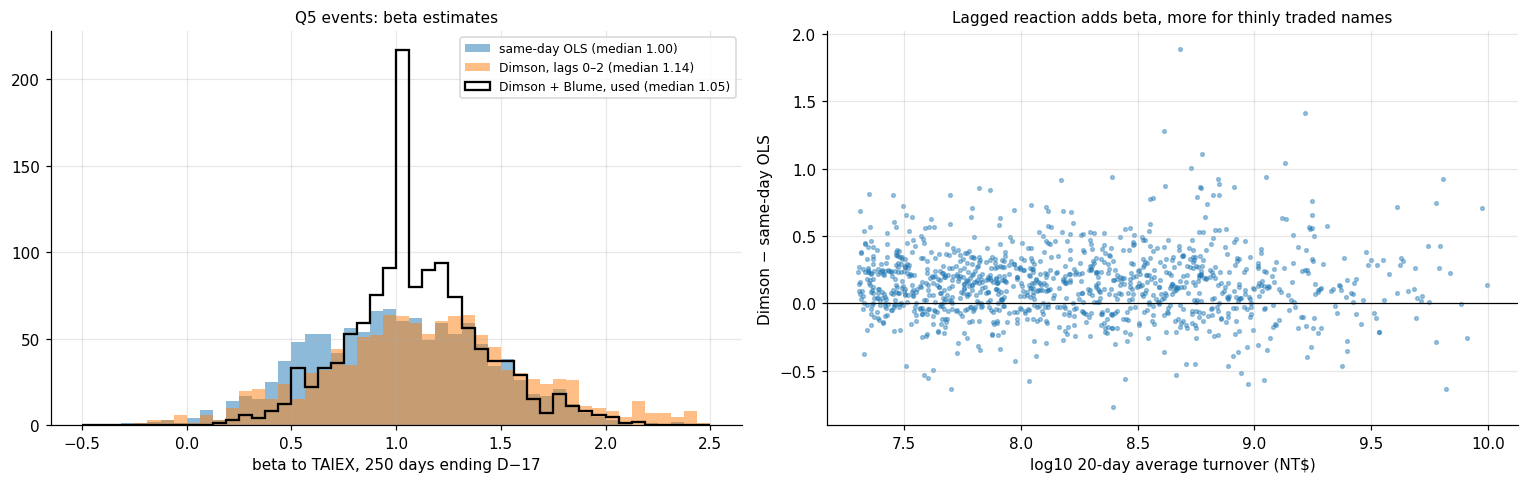

In [2]:
M_LAGS = np.column_stack([np.r_[np.full(k, np.nan), taiex[:T - k]] for k in range(DIMSON_LAGS + 1)])

def betas(j, end):
    rows = slice(max(0, end - BETA_WIN + 1), end + 1)
    y, X = Rv[rows, j], M_LAGS[rows]
    ok = np.isfinite(y) & np.isfinite(X).all(1) & (np.abs(y) < 0.095)
    if ok.sum() < BETA_MIN:
        return np.nan, np.nan, ok.sum()
    y, X = y[ok], X[ok]
    ols = np.polyfit(X[:, 0], y, 1)[0]
    dim = np.linalg.lstsq(np.column_stack([np.ones(len(y)), X]), y, rcond=None)[0][1:].sum()
    return ols, dim, ok.sum()

B = np.array([betas(j, d - SIG_LAG) for j, d in zip(tr.j.values, tr.D.values)])
tr["beta_ols"], tr["beta_dimson"], tr["beta_obs"] = B[:, 0], B[:, 1], B[:, 2]
tr["beta"] = (0.67 * tr.beta_dimson + 0.33).fillna(1.0)
print(f"events without enough history (beta set to 1): {tr.beta_dimson.isna().sum()} of {len(tr)}")
print(tr[["beta_ols", "beta_dimson", "beta"]].describe().round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
bins = np.linspace(-0.5, 2.5, 49)
ax[0].hist(tr.beta_ols.dropna(), bins, alpha=.5, label=f"same-day OLS (median {tr.beta_ols.median():.2f})")
ax[0].hist(tr.beta_dimson.dropna(), bins, alpha=.5, label=f"Dimson, lags 0–2 (median {tr.beta_dimson.median():.2f})")
ax[0].hist(tr.beta, bins, histtype="step", color="k", lw=1.5, label=f"Dimson + Blume, used (median {tr.beta.median():.2f})")
ax[0].set_xlabel("beta to TAIEX, 250 days ending D−17"); ax[0].set_title("Q5 events: beta estimates", fontsize=10); ax[0].legend(fontsize=8)
ax[1].scatter(np.log10(tr.val20), tr.beta_dimson - tr.beta_ols, s=6, alpha=.4)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xlabel("log10 20-day average turnover (NT$)"); ax[1].set_ylabel("Dimson − same-day OLS")
ax[1].set_title("Lagged reaction adds beta, more for thinly traded names", fontsize=10)
plt.tight_layout(); plt.show()

## 3. P&L engine
**What this does.** For a set of events and a cell (k, h): each event holds +1 stock and −β TAIEX futures on days
D−k+1…D, then −1 stock and +β futures on days D+1…D+h. Costs: 20bp + β×2bp charged on D (the long leg and its hedge
close) and on D+h (the short leg and its hedge close). Returns the fixed-notional daily P&L (sum across open trades, the
headline from `backtest.ipynb`), the average-of-open daily P&L, the open-position count, and per-trade net returns.
`hedged=False` gives the unhedged trade for comparison.

In [3]:
OFF = np.arange(-K_MAX + 1, H_MAX + 1)
cost, hcost = COST_LEG_BPS / 1e4, HEDGE_BPS / 1e4

def prep(sub):
    D, J = sub.D.values, sub.j.values
    days = D[:, None] + OFF[None, :]
    valid = days < T
    days = np.clip(days, 0, T - 1)
    return {"days": days, "valid": valid, "rs": np.nan_to_num(Rv[days, J[:, None]]), "rm": HEDGE_R[days], "beta": sub.beta.values}

def book(P, k, h, hedged=True):
    useL = (OFF >= -k + 1) & (OFF <= 0) & (k >= 1)
    useS = (OFF >= 1) & (OFF <= h)
    use = (useL | useS)[None, :] & P["valid"]
    sign = np.where(OFF <= 0, 1.0, -1.0)[None, :]
    b = P["beta"] * hedged
    pnl = np.where(use, sign * (P["rs"] - b[:, None] * P["rm"]), 0.0)
    leg_cost = cost + np.abs(b) * hcost
    if k >= 1: pnl[:, OFF == 0] -= leg_cost[:, None]
    if h >= 1: pnl[:, OFF == h] -= leg_cost[:, None]
    s = np.zeros(T); c = np.zeros(T)
    np.add.at(s, P["days"][use], pnl[use]); np.add.at(c, P["days"][use], 1)
    return {"fixed": pd.Series(s, cal), "avg": pd.Series(np.divide(s, c, out=np.zeros(T), where=c > 0), cal), "npos": pd.Series(c, cal),
            "net": pnl.sum(1), "long": pnl[:, OFF <= 0].sum(1), "short": pnl[:, OFF >= 1].sum(1)}

sharpe = lambda d: d.mean() / d.std() * np.sqrt(252) if d.std() > 0 else np.nan

## 4. In-sample optimisation grid
**What this does.** Re-runs the `insample.ipynb` grid for the hedged trade, on in-sample events only and the in-sample
calendar: every long entry D−k (k = 2…15, or no long) × every short length h (1…20 days from the close of D, or no
short). The objective is the **fixed-notional Sharpe**, as `backtest.ipynb` recommended. The unhedged grid is shown next
to it on the same colour scale. The black box marks the best hedged cell, the dashed box the frozen D−12 / 5-day trade.

hedged   : best in-sample fixed-notional Sharpe 2.01 at buy D−6, short 5d (147bp/trade, t = 3.7); frozen D−12/5d: 1.47
unhedged : best in-sample fixed-notional Sharpe 1.46 at buy D−5, short 5d (138bp/trade, t = 3.3); frozen D−12/5d: 0.88


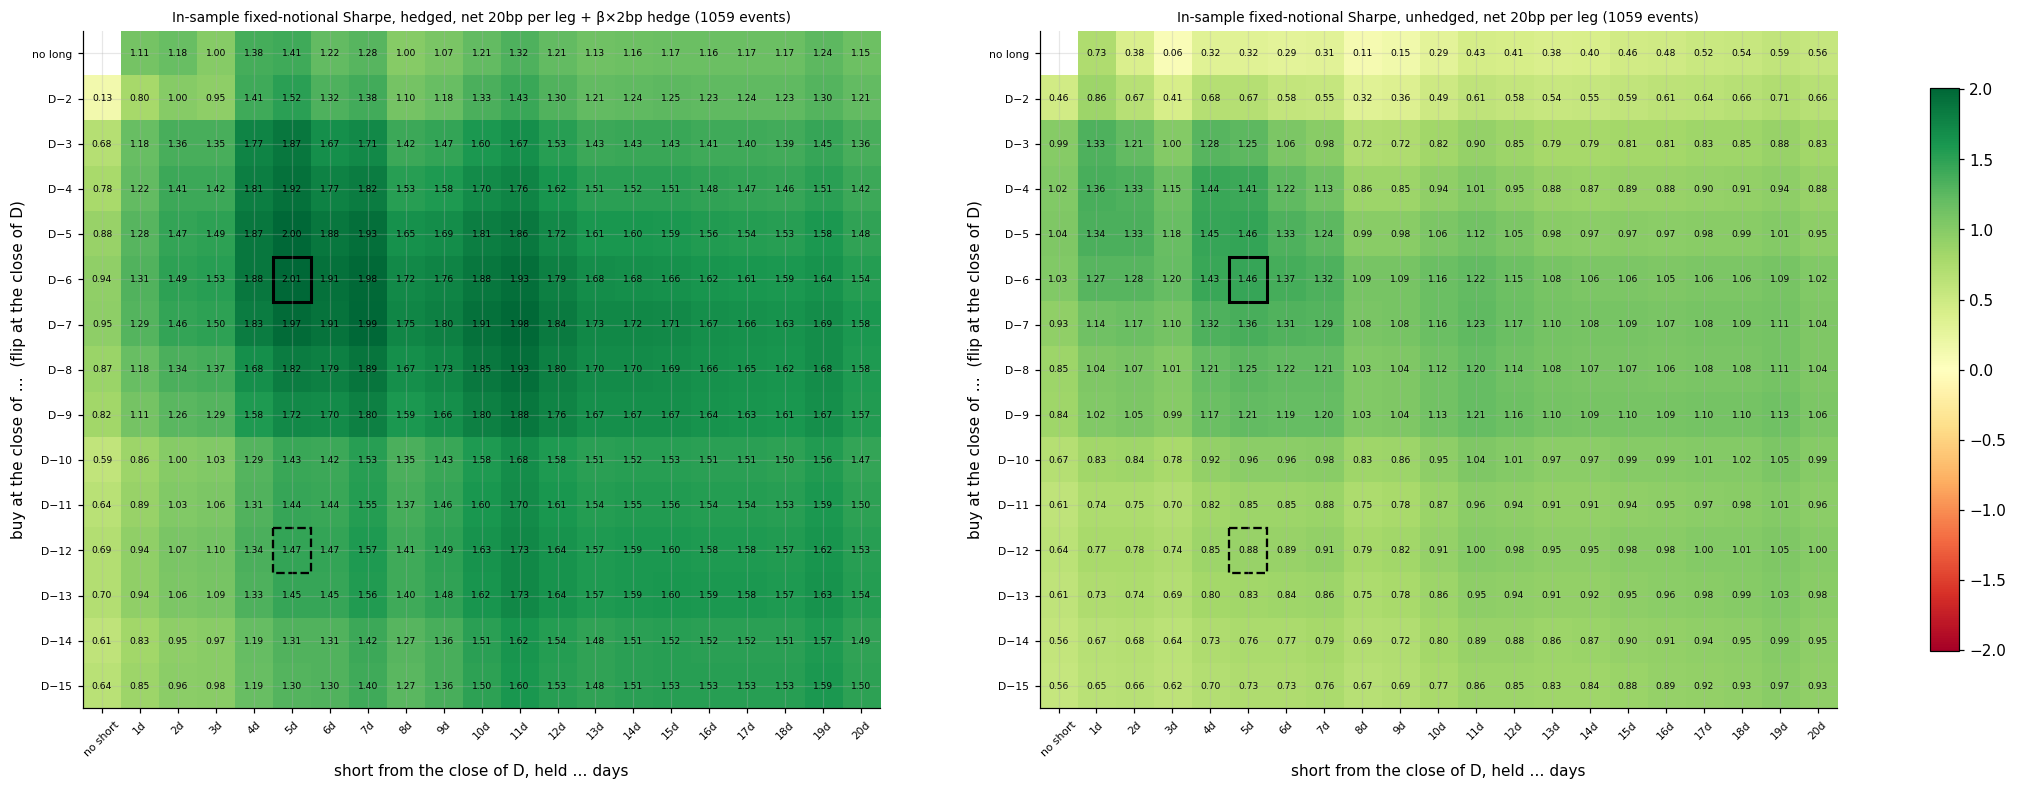

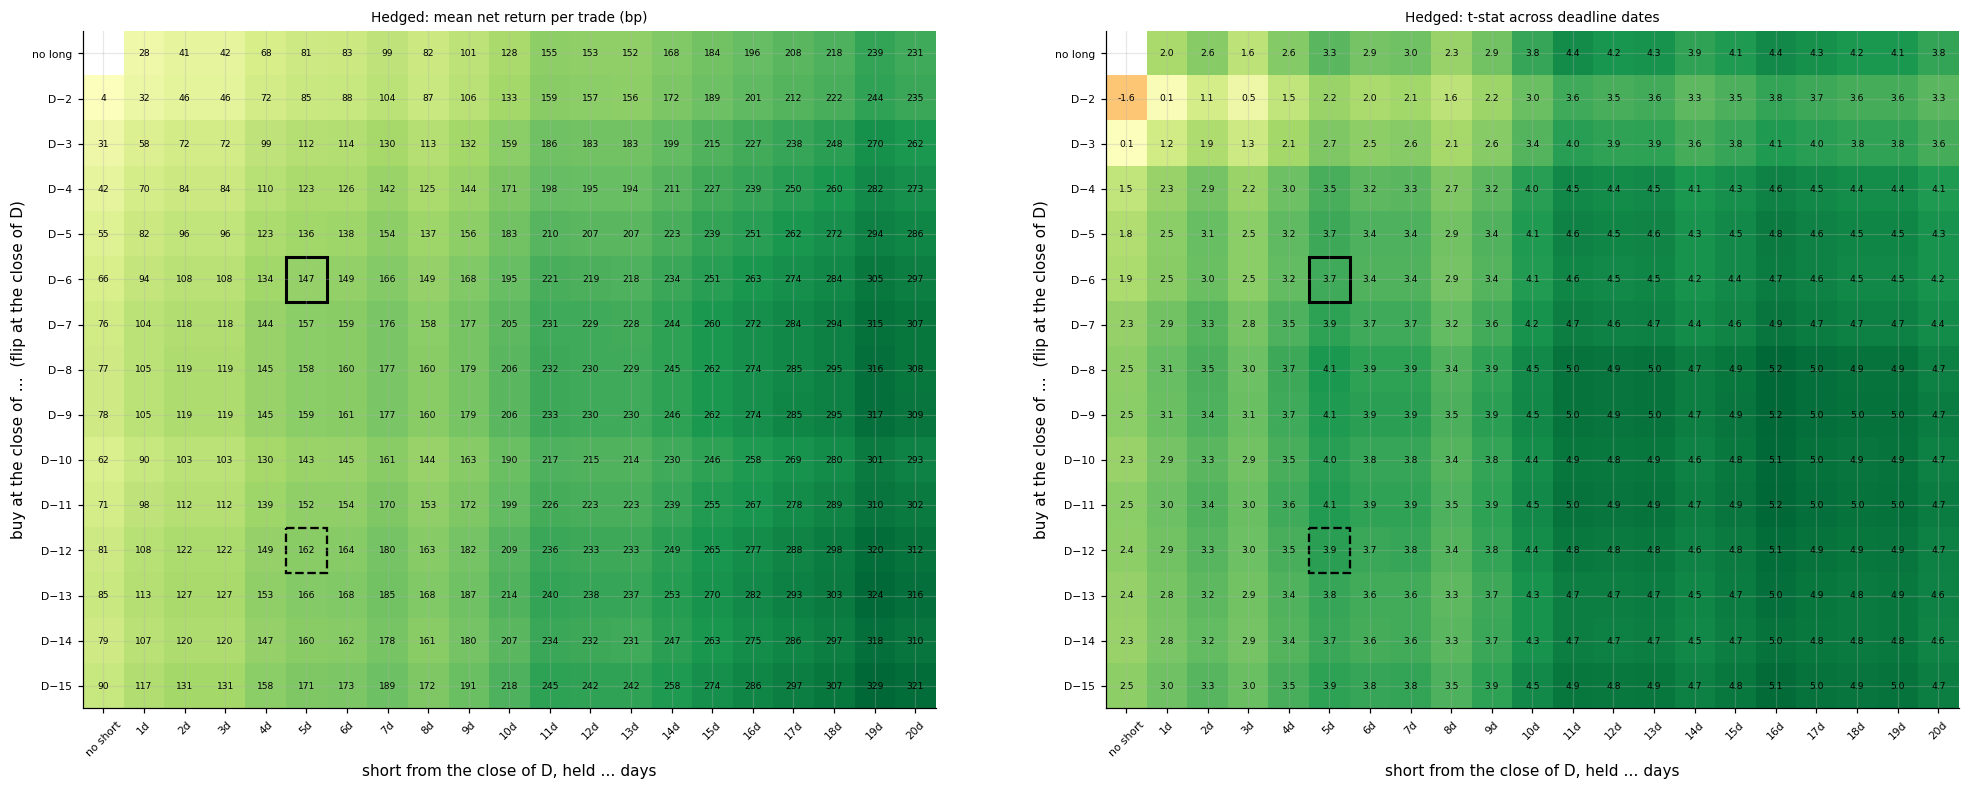

top 10 hedged cells:
      sharpe      bp     t  unhedged sharpe
k h                                        
6 5     2.01  147.24  3.65             1.46
5 5     2.00  135.65  3.70             1.46
7 7     1.99  175.59  3.67             1.29
6 7     1.98  165.77  3.41             1.32
7 11    1.98  231.12  4.72             1.23
  5     1.97  157.06  3.91             1.36
6 11    1.93  221.30  4.55             1.22
5 7     1.93  154.18  3.45             1.24
8 11    1.93  232.30  4.97             1.20
4 5     1.92  123.45  3.52             1.41

hedged long-only column (no short):
k         2     3     4     5     6     7     8     9     10    11    12   13    14    15
sharpe  0.13  0.68  0.78  0.88  0.94  0.95  0.87  0.82  0.59  0.64  0.69  0.7  0.61  0.64
hedged short-only row (no long):
h         1     2    3     4     5     6     7    8     9     10    11    12    13    14    15    16    17    18    19    20
sharpe  1.11  1.18  1.0  1.38  1.41  1.22  1.28  1.0  1.07  1.21  1.32  1.21

In [4]:
ins = tr[tr.period == "in-sample"].reset_index(drop=True)
P_in = prep(ins)
KS, HS = np.r_[0, np.arange(2, K_MAX + 1)], np.arange(0, H_MAX + 1)
grid = lambda: pd.DataFrame(np.nan, index=pd.Index(KS, name="k"), columns=pd.Index(HS, name="h"))
G = {nm: {m: grid() for m in ("sharpe", "bp", "t")} for nm in ("hedged", "unhedged")}
for nm, hd in [("hedged", True), ("unhedged", False)]:
    for k in KS:
        for h in HS:
            if k == 0 and h == 0: continue
            r = book(P_in, k, h, hd)
            G[nm]["sharpe"].loc[k, h] = sharpe(r["fixed"].iloc[:CUT])
            G[nm]["bp"].loc[k, h] = r["net"].mean() * 1e4
            pdm = pd.Series(r["net"]).groupby(ins.Ddate.values).mean()
            G[nm]["t"].loc[k, h] = pdm.mean() / pdm.std() * np.sqrt(len(pdm))
for nm in G:
    b_ = G[nm]["sharpe"].stack().idxmax()
    print(f"{nm:9s}: best in-sample fixed-notional Sharpe {G[nm]['sharpe'].loc[b_]:.2f} at buy D−{b_[0]}, short {b_[1]}d "
          f"({G[nm]['bp'].loc[b_]:.0f}bp/trade, t = {G[nm]['t'].loc[b_]:.1f}); frozen D−{K}/{H}d: {G[nm]['sharpe'].loc[K, H]:.2f}")
BEST = G["hedged"]["sharpe"].stack().idxmax()

def heat(a, M, ttl, fmt, v=None, mark=True):
    v = v or np.nanmax(np.abs(M.values))
    im = a.imshow(M.values, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
    a.set_xticks(range(len(HS)), [f"{h}d" if h else "no short" for h in HS], rotation=45, fontsize=7)
    a.set_yticks(range(len(KS)), [f"D−{k}" if k else "no long" for k in KS], fontsize=7)
    a.set_xlabel("short from the close of D, held … days"); a.set_ylabel("buy at the close of …  (flip at the close of D)")
    for (i, j), val in np.ndenumerate(M.values):
        if np.isfinite(val): a.text(j, i, fmt.format(val), ha="center", va="center", fontsize=6)
    if mark:
        a.add_patch(plt.Rectangle((list(HS).index(BEST[1]) - .5, list(KS).index(BEST[0]) - .5), 1, 1, fill=False, lw=2, ec="k"))
        a.add_patch(plt.Rectangle((list(HS).index(H) - .5, list(KS).index(K) - .5), 1, 1, fill=False, lw=1.5, ec="k", ls="--"))
    a.set_title(ttl, fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
v = max(np.nanmax(np.abs(G[nm]["sharpe"].values)) for nm in G)
for a, nm in zip(axes, ("hedged", "unhedged")):
    im = heat(a, G[nm]["sharpe"], f"In-sample fixed-notional Sharpe, {nm}, net {COST_LEG_BPS}bp per leg"
              + (f" + β×{HEDGE_BPS}bp hedge" if nm == "hedged" else "") + f" ({len(ins)} events)", "{:.2f}", v)
plt.colorbar(im, ax=axes, fraction=.015); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
heat(axes[0], G["hedged"]["bp"], "Hedged: mean net return per trade (bp)", "{:.0f}")
heat(axes[1], G["hedged"]["t"], "Hedged: t-stat across deadline dates", "{:.1f}")
plt.show()

top = G["hedged"]["sharpe"].stack().sort_values(ascending=False).head(10).rename("sharpe").to_frame()
for m in ("bp", "t"): top[m] = [G["hedged"][m].loc[i] for i in top.index]
top["unhedged sharpe"] = [G["unhedged"]["sharpe"].loc[i] for i in top.index]
print("top 10 hedged cells:"); print(top.round(2).to_string())
print("\nhedged long-only column (no short):"); print(G["hedged"]["sharpe"][0].drop(0).round(2).to_frame("sharpe").T.to_string())
print("hedged short-only row (no long):"); print(G["hedged"]["sharpe"].loc[0].drop(0).round(2).to_frame("sharpe").T.to_string())

## 5. Backtest: in-sample and out-of-sample
**What this does.** Runs the frozen D−12 / 5-day trade hedged and unhedged on all events, plus the best hedged cell from
the grid above. The out-of-sample period was not used by the grid. The in-sample best cell was picked from 335
cells, so its in-sample Sharpe is optimistic and only its out-of-sample number is a fair test.

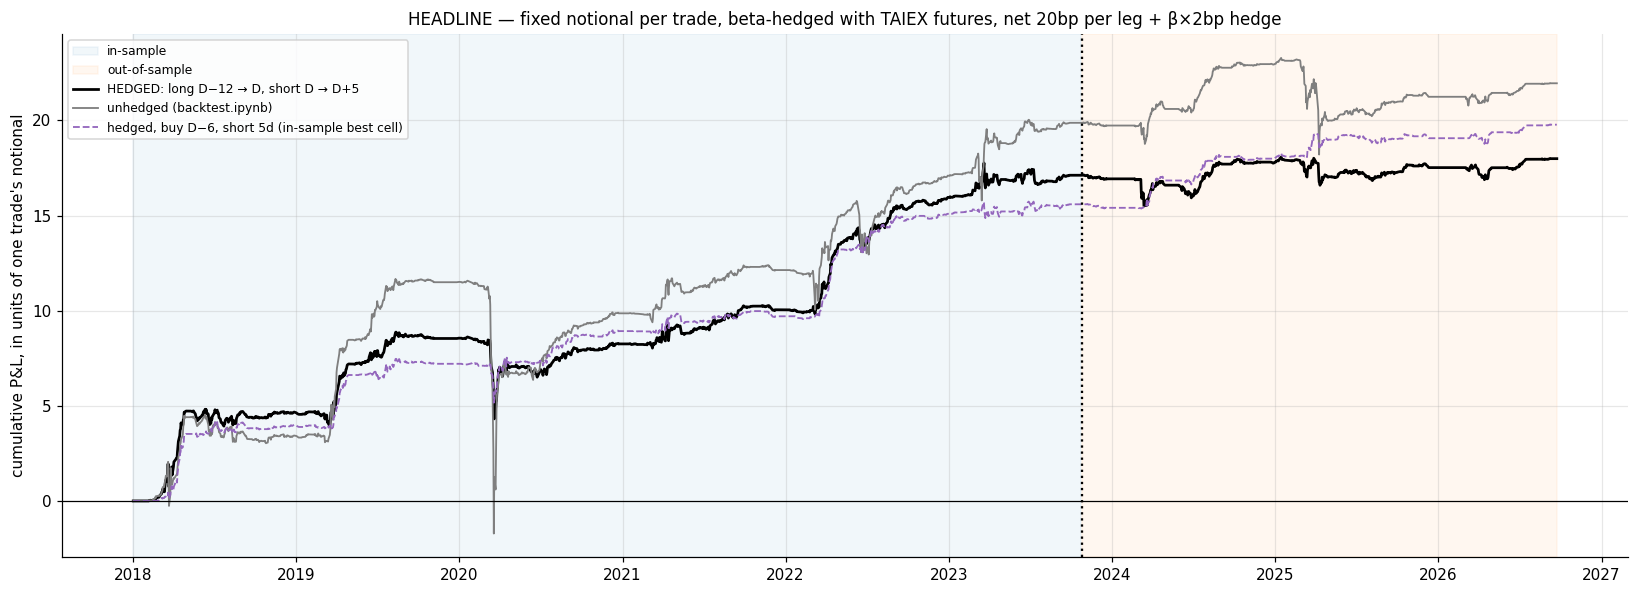

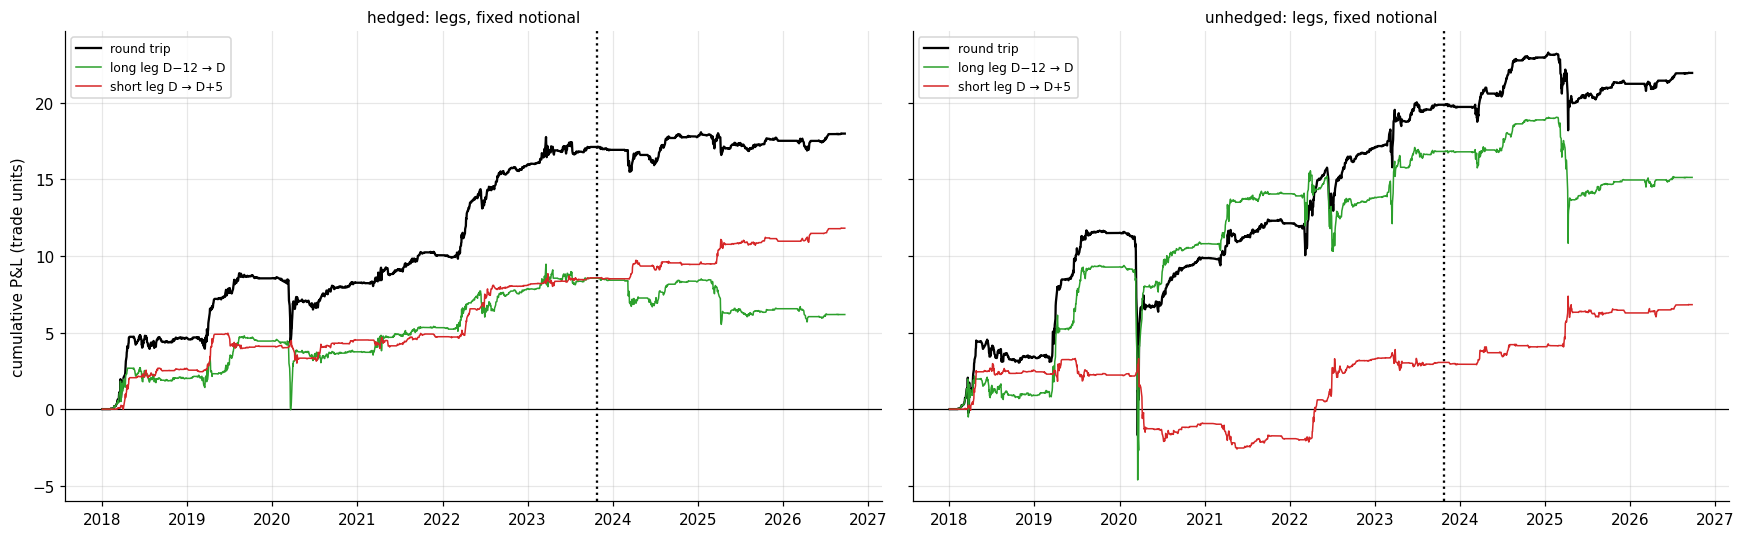

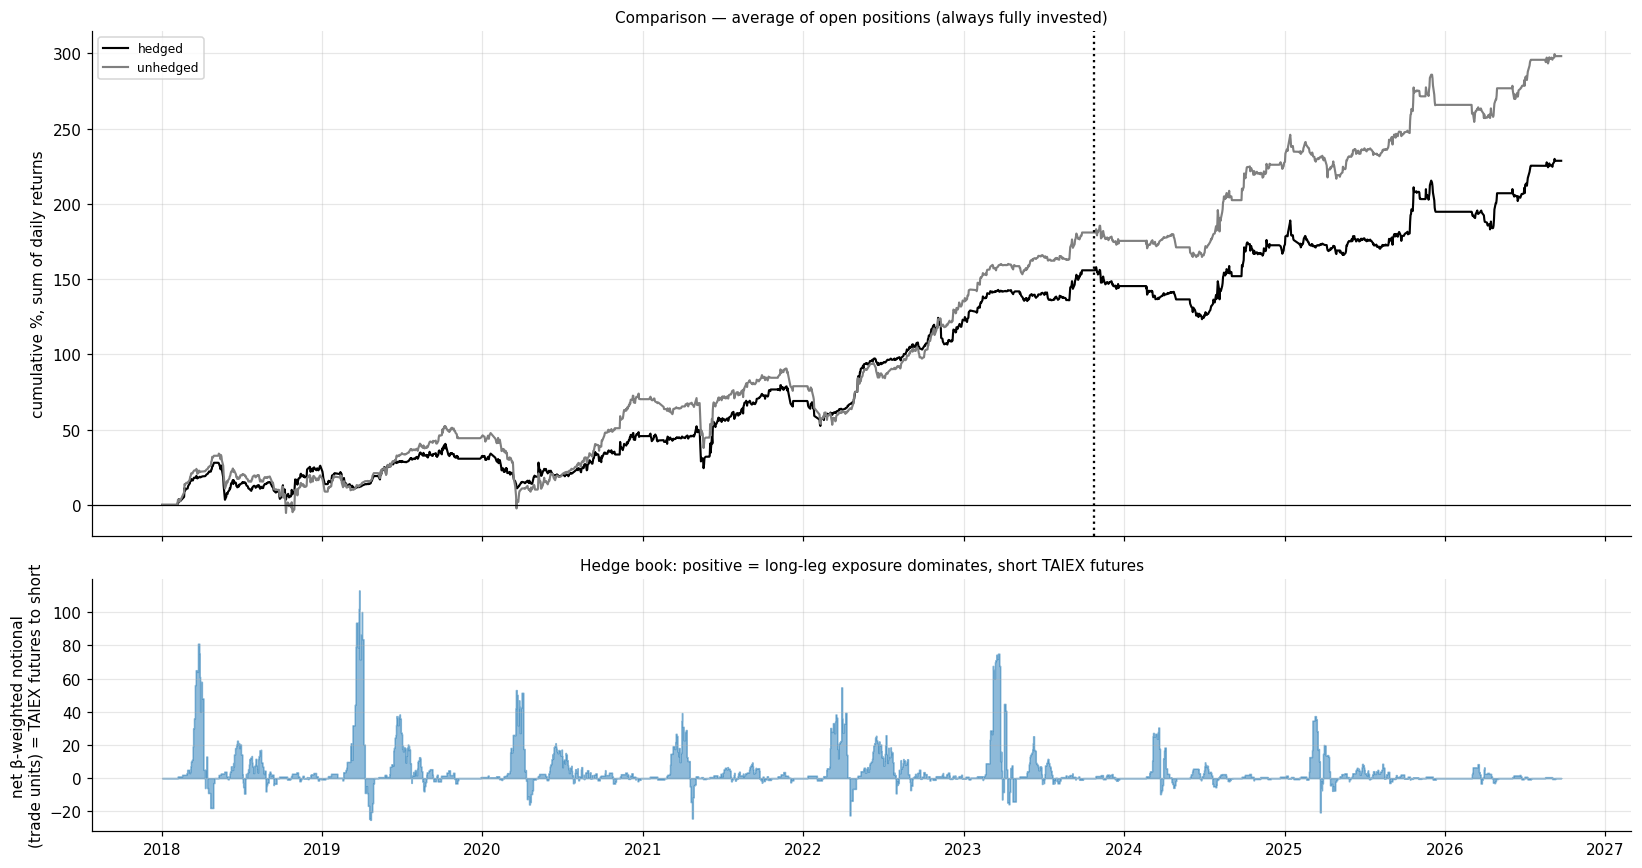

In [5]:
P_all = prep(tr)
RUNS = {"hedged": book(P_all, K, H, True), "unhedged": book(P_all, K, H, False),
        f"hedged best cell (D−{BEST[0]}, {BEST[1]}d)": book(P_all, *BEST, True)}
LONG = {"hedged": book(P_all, K, 0, True), "unhedged": book(P_all, K, 0, False)}
SHORT = {"hedged": book(P_all, 0, H, True), "unhedged": book(P_all, 0, H, False)}
is_day = np.arange(T) < CUT

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axvspan(cal[0], cal[CUT - 1], color="C0", alpha=.06, label="in-sample")
ax.axvspan(cal[CUT], cal[-1], color="C1", alpha=.06, label="out-of-sample")
ax.plot(cal, RUNS["hedged"]["fixed"].cumsum(), color="k", lw=1.8, label=f"HEDGED: long D−{K} → D, short D → D+{H}")
ax.plot(cal, RUNS["unhedged"]["fixed"].cumsum(), color="C7", lw=1.2, label="unhedged (backtest.ipynb)")
nm3 = list(RUNS)[2]
ax.plot(cal, RUNS[nm3]["fixed"].cumsum(), color="C4", lw=1.2, ls="--", label=f"hedged, buy D−{BEST[0]}, short {BEST[1]}d (in-sample best cell)")
ax.axvline(cal[CUT], color="k", ls=":"); ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("cumulative P&L, in units of one trade's notional")
ax.set_title(f"HEADLINE — fixed notional per trade, beta-hedged with TAIEX futures, net {COST_LEG_BPS}bp per leg + β×{HEDGE_BPS}bp hedge", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for a, nm in zip(ax, ("hedged", "unhedged")):
    a.axvline(cal[CUT], color="k", ls=":"); a.axhline(0, color="k", lw=.8)
    a.plot(cal, RUNS[nm]["fixed"].cumsum(), color="k", lw=1.5, label="round trip")
    a.plot(cal, LONG[nm]["fixed"].cumsum(), color="C2", lw=1, label=f"long leg D−{K} → D")
    a.plot(cal, SHORT[nm]["fixed"].cumsum(), color="C3", lw=1, label=f"short leg D → D+{H}")
    a.set_title(f"{nm}: legs, fixed notional", fontsize=10); a.legend(fontsize=8, loc="upper left")
ax[0].set_ylabel("cumulative P&L (trade units)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
for nm, c in [("hedged", "k"), ("unhedged", "C7")]:
    ax[0].plot(cal, RUNS[nm]["avg"].cumsum() * 100, color=c, lw=1.4, label=nm)
ax[0].axvline(cal[CUT], color="k", ls=":"); ax[0].axhline(0, color="k", lw=.8); ax[0].legend(fontsize=8)
ax[0].set_ylabel("cumulative %, sum of daily returns"); ax[0].set_title("Comparison — average of open positions (always fully invested)", fontsize=10)
expo = pd.Series(0.0, cal)
np.add.at(expo.values, P_all["days"][:, (OFF >= -K + 1) & (OFF <= 0)].ravel(), np.repeat(P_all["beta"], K))
np.add.at(expo.values, P_all["days"][:, (OFF >= 1) & (OFF <= H)].ravel(), -np.repeat(P_all["beta"], H))
ax[1].fill_between(cal, expo, color="C0", alpha=.5, step="mid")
ax[1].set_ylabel("net β-weighted notional\n(trade units) = TAIEX futures to short")
ax[1].set_title("Hedge book: positive = long-leg exposure dominates, short TAIEX futures", fontsize=10)
plt.tight_layout(); plt.show()

## 6. Statistics
**What this does.** Per period: fixed-notional Sharpe, total P&L and max drawdown, each leg's Sharpe, mean net bp per
trade, hit rate, t-stat across deadline dates, and the **realised beta** of the daily P&L to TAIEX (slope of strategy P&L
on TAIEX return, on days with a position). A working hedge brings that slope near 0. Then by year, and the worst dates.

In [6]:
def realised_beta(d, mask):
    return np.polyfit(taiex[mask], d.values[mask], 1)[0]

rows = {}
for nm, r in RUNS.items():
    tl = {"hedged": LONG["hedged"], "unhedged": LONG["unhedged"]}.get(nm)
    ts = {"hedged": SHORT["hedged"], "unhedged": SHORT["unhedged"]}.get(nm)
    for per, dm in [("in-sample", is_day), ("out-of-sample", ~is_day)]:
        tm = (tr.period == per).values
        fx = r["fixed"][dm]; eq = fx.cumsum(); op = dm & (r["npos"].values > 0)
        pdm = pd.Series(r["net"][tm]).groupby(tr.Ddate.values[tm]).mean()
        rows[(nm, per)] = {"fixed-notional Sharpe": sharpe(fx), "total P&L (trade units)": fx.sum(), "max drawdown (trade units)": (eq - eq.cummax()).min(),
                           "long-leg Sharpe": sharpe(tl["fixed"][dm]) if tl else np.nan, "short-leg Sharpe": sharpe(ts["fixed"][dm]) if ts else np.nan,
                           "avg-of-open Sharpe": sharpe(r["avg"][dm]), "trades": tm.sum(), "mean net / trade bp": r["net"][tm].mean() * 1e4,
                           "long leg / trade bp": r["long"][tm].mean() * 1e4, "short leg / trade bp": r["short"][tm].mean() * 1e4,
                           "hit rate": (r["net"][tm] > 0).mean(), "t (per date)": pdm.mean() / pdm.std() * np.sqrt(len(pdm)),
                           "realised beta to TAIEX": realised_beta(r["fixed"], op), "corr with TAIEX": np.corrcoef(r["fixed"].values[op], taiex[op])[0, 1]}
print(pd.DataFrame(rows).round(3).to_string())

yr = []
for y, g in tr.groupby(tr.Ddate.dt.year):
    dm = cal.year == y; tm = (tr.Ddate.dt.year == y).values
    yr.append({"year": y, "trades": len(g), "hedged bp": RUNS["hedged"]["net"][tm].mean() * 1e4, "unhedged bp": RUNS["unhedged"]["net"][tm].mean() * 1e4,
               "hedged long bp": RUNS["hedged"]["long"][tm].mean() * 1e4, "hedged short bp": RUNS["hedged"]["short"][tm].mean() * 1e4,
               "hedged Sharpe": sharpe(RUNS["hedged"]["fixed"][dm]), "unhedged Sharpe": sharpe(RUNS["unhedged"]["fixed"][dm]),
               "TAIEX %": taiex[dm].sum() * 100, "period": "/".join(sorted(g.period.unique()))})
print("\n" + pd.DataFrame(yr).set_index("year").round(2).to_string())

w = pd.DataFrame({"Ddate": tr.Ddate, "hedged": RUNS["hedged"]["net"], "unhedged": RUNS["unhedged"]["net"]}).groupby("Ddate").agg(
    trades=("hedged", "size"), hedged=("hedged", "sum"), unhedged=("unhedged", "sum"))
print("\nworst 8 deadline dates unhedged (total P&L, trade units), and the same dates hedged:")
print(w.sort_values("unhedged").head(8).round(2).to_string())
print("\nworst 8 deadline dates hedged:")
print(w.sort_values("hedged").head(8).round(2).to_string())

                              hedged                unhedged               hedged best cell (D−6, 5d)              
                           in-sample out-of-sample in-sample out-of-sample                  in-sample out-of-sample
fixed-notional Sharpe          1.469         0.240     0.881         0.340                      2.006         1.622
total P&L (trade units)       17.120         0.872    19.876         2.078                     15.593         4.185
max drawdown (trade units)    -4.562        -1.637   -13.384        -5.076                     -2.306        -0.744
long-leg Sharpe                0.695        -0.612     0.642        -0.221                        NaN           NaN
short-leg Sharpe               1.407         1.430     0.321         1.080                        NaN           NaN
avg-of-open Sharpe             1.168         0.954     1.231         1.405                      0.760         1.205
trades                      1059.000       208.000  1059.000       208.0

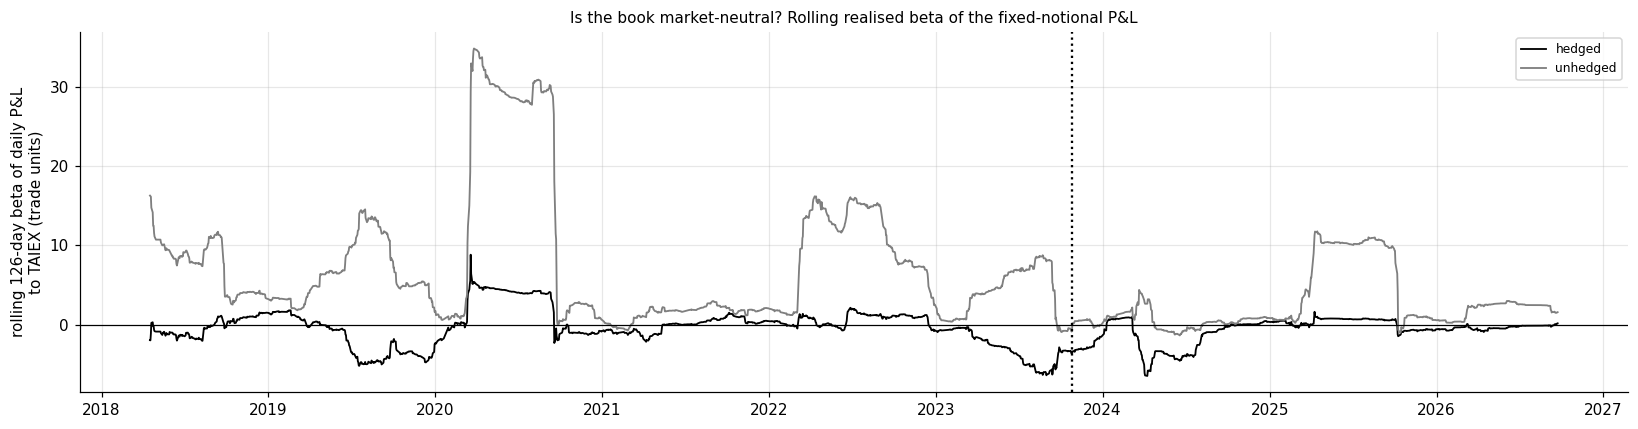

In [7]:
fig, ax = plt.subplots(figsize=(15, 4))
for nm, c in [("hedged", "k"), ("unhedged", "C7")]:
    op = RUNS[nm]["npos"] > 0
    d, m = RUNS[nm]["fixed"].where(op), pd.Series(taiex, cal).where(op)
    ax.plot(cal, d.rolling(126, min_periods=40).cov(m) / m.rolling(126, min_periods=40).var(), color=c, lw=1.2, label=nm)
ax.axhline(0, color="k", lw=.8); ax.axvline(cal[CUT], color="k", ls=":")
ax.set_ylabel("rolling 126-day beta of daily P&L\nto TAIEX (trade units)"); ax.legend(fontsize=8)
ax.set_title("Is the book market-neutral? Rolling realised beta of the fixed-notional P&L", fontsize=10)
plt.tight_layout(); plt.show()

**Interpretation.**
- **The hedge works.** Correlation of daily P&L with TAIEX falls from 0.42 to 0.05, and the realised beta of the book
  from 10.5 / 4.5 trade units (in / out of sample) to 0.6 / −0.03. The worst date, 2020-03-20 (12 trades), goes from
  −4.5 to −1.7 trade units; max drawdown falls from −13.4 to −4.6 in-sample and from −5.1 to −1.6 out-of-sample.
- **Frozen D−12 / 5-day trade:** in-sample Sharpe 0.88 → **1.47** hedged, but out-of-sample 0.34 → **0.24**. Hedging
  removes risk, and the long leg's out-of-sample loss is still there.
- **The out-of-sample long-leg loss is not market beta.** Hedged, the long leg still loses −114bp per trade
  out-of-sample (Sharpe −0.61), worse than unhedged (−82bp). In 2024–26 TAIEX rose about 30% a year, driven by TSMC and
  other large caps, while these small caps lagged it. A cap-weighted hedge then loses on the hedge as well. A
  small-cap or equal-weight hedge (e.g. the TPEx index, or the mid-cap 0051 ETF) would match these names better and is
  worth testing.
- **The short leg is the robust part.** Hedged short leg D → D+5: Sharpe **1.41 in-sample, 1.43 out-of-sample**
  (+81 → +156bp per trade). The hedged short-only row of the grid is 1.0–1.4 for every holding length, so this is not a
  single lucky cell.
- **The grid prefers a shorter long:** buy at D−3 to D−9, short 4–7 or 10–11 days, a broad plateau around 1.8–2.0.
  The best cell, **D−6 / 5 days**, scores 2.01 in-sample and **1.62 out-of-sample** (+201bp per trade, t = 1.9,
  max drawdown −0.74 trade units). It was picked from 335 cells, but it sits inside the plateau and holds up out of sample.
  A 6-day long avoids most of the D−12 → D−7 window, which is where the long loses out-of-sample.
- **Caveats:** stock returns stand in for single-stock futures on both legs (as in `backtest.ipynb`); only about 40% of
  Q5 events have a listed future (`insample.ipynb` §4). Out-of-sample has 208 trades on 103 dates, so t ≈ 1.9 is
  suggestive rather than conclusive. Per-position hedging at 2bp is conservative compared with hedging the netted book;
  rounding to whole contracts (TMF ≈ NT$0.5m) leaves some residual beta on a small book.